## Simple lat-lon Panel Plots 

In [2]:
import xarray as xr
import matplotlib.pyplot as mp
import numpy as np
import glob as glob
import os as os
from pathlib import Path

import cartopy.crs as ccrs


In [3]:
# Cases

dir0 = '/glade/derecho/scratch/rneale/archive/'
dir_climo = '/glade/campaign/cgd/amp/amwg/climo/'
dir_obs = '/glade/campaign/cgd/amp/amwg/amwg_data/obs_data/'
dir_fig = '/glade/u/home/rneale/python/python-figs/CAM7_CESM3_dev/'


In [80]:
# Data

var = 'TPERT_ZM'
seas = 'JJA'

#dcases = {'TRMM'                   : 'TRMM',
#         'CAM7-no_tpert'          : 'f.cam6_4_130.FLTHIST_ne30.cam7-tpert.001',
#         'CAM7-sgh30_tpert'       : 'f.cam6_4_130.FLTHIST_ne30.cam7-tpert.002',
#         }
dcases = {'TPERT_ZM'       : 'f.cam6_4_130.FLTHIST_ne30.cam7-tpert.002',
         }


case_names = list(dcases.keys())
cases = [v for v in dcases.values()]
print(case)

obs_case = ['TRMM']

f.cam6_4_130.FLTHIST_ne30.cam7-tpert.002


In [93]:
# Plot resources.
ncols = 1
nrows = 3

dpproj = ccrs.PlateCarree()



clevs = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9,10,11,12,13,14,15,16,17,18,19,20,21,22])*0.25
aclevs = [-6, -5, -4, -3, -2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2, 3, 4, 5,6]

pclevs = clevs
cmap = 'terrain_r'

Case ( 0 ) =  TPERT_ZM


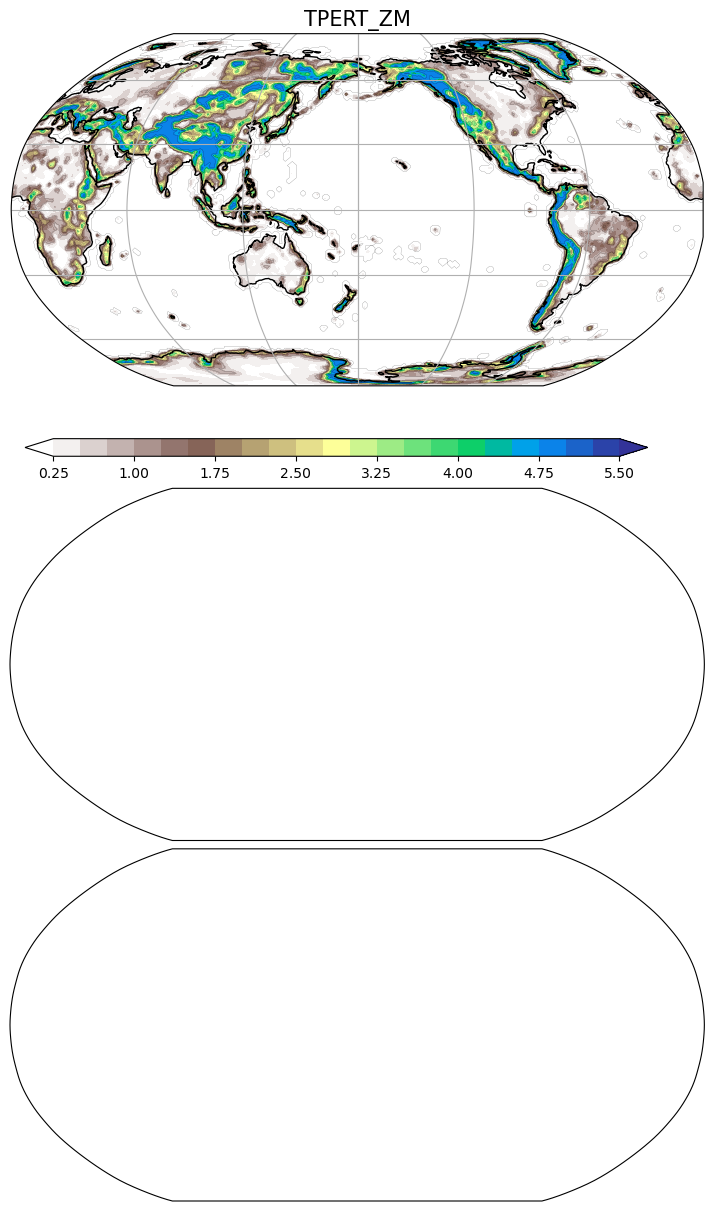

In [94]:
# Figures

fig, axs = mp.subplots(nrows=nrows, ncols=ncols, figsize=[nrows*18, ncols*12],
                   subplot_kw={'projection': ccrs.Robinson(central_longitude=180.)}, constrained_layout=True)    


ax = axs.flatten()

for icase, cname in enumerate(case_names):    

    print('Case (',icase,') = ',cname)
    
    case = cases[icase]

    if cname in obs_case:
        file_in = dir_obs+cname+'_'+seas+'_climo.nc'
        vscale = 1.
    else:
        file_in = dir0+case+'/atm/'+case+'_1995-1996_JJA_av.nc'
        vscale = 1.
        if icase == 2 : vscale = vscale *1.0
    
    pvar = xr.open_dataset(file_in).squeeze()[var]*vscale

    pplot = ax[icase].contourf(pvar.lon, pvar.lat, pvar, transform=dpproj, cmap=cmap,levels=pclevs,extend='both')  

    if icase==0:
        cbar_area = [0.02, -0.2, 0.9, 0.05 ] 
        cbar = ax[icase].inset_axes(cbar_area, transform=ax[icase].transAxes)
        cbar = fig.colorbar(pplot,cax=cbar, orientation = 'horizontal')
    
    pplot = ax[icase].contour(pvar.lon, pvar.lat, pvar, transform=dpproj, colors='black', linewidths=0.1)

   
    
    ax[icase].set_title(cname, fontsize=15)
    ax[icase].coastlines(linewidth=1,color='black',resolution='110m')
    ax[icase].gridlines()
#    ax[icase].set_ylim(-45., 45.)    
    

